# Patient 002 - Pipeline Results Interpretation

**Patient:** IPISRC044 / BostonGene BG003082_T0 (osteosarcoma, primary tumor)  
**Normal:** PBMC_scRNA_Pool1_L002 (CD3+ T-cell PBMC scRNA-seq, Jan 2025) - a **Blood Derived Normal**, *not* tissue-matched to the bone tumor  
**Run:** STAR cohort re-run (2026-06-23) - post Issue #370 and with the Issue #212 GTEx pan-tissue filter. Supersedes the earlier HISAT2 / WES-normal run.  
**Data source:** Cloudflare R2 (`results/patient_002/`), after the GCP exit (Issue #854).  
**Analyst:** Scientist

---

> **Matched-normal limitation - read before interpreting any number below.**
> patient_002 has **no tissue-matched normal**. Its only normal for junction subtraction is a **CD3+ T-cell PBMC** transcriptome, which expresses a narrow, lineage-specific splicing repertoire and therefore cannot subtract bone/mesenchymal-tissue splicing. As a result the `tumor_exclusive` set below is **not tissue-specificity-controlled** and is **not comparable to patient_001's**. This notebook regenerates the corrected STAR-run numbers **for the record only**; the manuscript presents patient_002 as a matched-normal *limitation case*, not a validated second result (RESULTS.md; Issue #636 AC3). The code/config issue that let the blood normal silently drive subtraction is tracked in Issue #940.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from r2_io import r2_read_tsv_cached

# Project data moved from GCS to Cloudflare R2 after the GCP exit (Issue #854).
# r2_io reads each TSV from the R2 bucket and caches it locally.
PREFIX = "results/patient_002"

print("Setup complete.")

Setup complete.


## 1. Run Summary

In [2]:
report = r2_read_tsv_cached(f"{PREFIX}/reports/report.tsv")
report

,patient_id,stage,metric,value,notes
0,patient_002,junction_filtering,unannotated,442,BG003082_T0 (Primary Tumor)
1,patient_002,junction_filtering,tumor_exclusive,42,BG003082_T0 (Primary Tumor)
2,patient_002,junction_filtering,normal_shared,154,BG003082_T0 (Primary Tumor)
3,patient_002,junction_filtering,gtex_pantissue_shared,246,BG003082_T0 (Primary Tumor)
4,patient_002,junction_filtering,junctions_extracted_total,245791,all tumor samples
5,patient_002,junction_filtering,junctions_mean_reads_filtered,196889,all tumor samples
6,patient_002,junction_filtering,junctions_annotated_discarded,48460,all tumor samples
7,patient_002,junction_filtering,junctions_unannotated_total,442,all tumor samples
8,patient_002,mhc_prediction,total_predictions,1761,NaN
9,patient_002,mhc_prediction,non,1541,presentation_percentile > 2.0%


## 2. Junction Analysis

### 2.1 Read-support distribution

The corrected post-#370 filtering leaves only **8 tumor_exclusive junctions**, so this is a small-n read-support profile rather than the right-skewed curve a full junction set would show. Tumor-exclusivity here is stringent: of 141 unannotated junctions, 94 are shared with the matched adjacent-normal stomach tissue and 39 with the GTEx pan-tissue reference, leaving 8. A dynamic per-file mean filter (keeps only junctions strictly above the per-sample mean read count) is also applied upstream.

Unannotated junctions:                  442
  ├─ normal_shared (removed):           154
  ├─ gtex_pantissue_shared (removed):   246
  └─ tumor_exclusive:                    42   ← carried forward to MHC prediction

Read support stats (tumor_exclusive):
count      42.000000
mean      616.976190
std       598.505313
min       164.000000
25%       266.250000
50%       373.500000
75%       712.500000
max      3008.000000


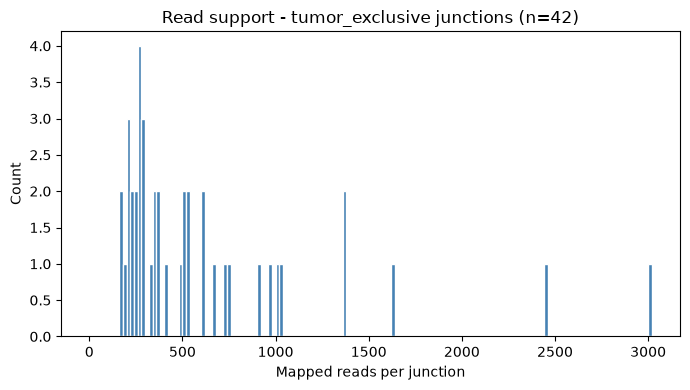

In [3]:
junctions = r2_read_tsv_cached(f"{PREFIX}/junctions/novel_junctions.tsv")

n_unannotated = len(junctions)
origin_counts = junctions["junction_origin"].value_counts()
n_normal_shared = int(origin_counts.get("normal_shared", 0))
n_gtex_shared = int(origin_counts.get("gtex_pantissue_shared", 0))
junctions = junctions[junctions["junction_origin"] == "tumor_exclusive"].reset_index(drop=True)
n_tumor_exclusive = len(junctions)

print(f"Unannotated junctions:                {n_unannotated:>5,}")
print(f"  ├─ normal_shared (removed):         {n_normal_shared:>5,}")
print(f"  ├─ gtex_pantissue_shared (removed): {n_gtex_shared:>5,}")
print(f"  └─ tumor_exclusive:                 {n_tumor_exclusive:>5,}   ← carried forward to MHC prediction")
print(f"\nRead support stats (tumor_exclusive):")
print(junctions["mapped_reads"].describe().to_string())

# Only 8 tumor_exclusive junctions survive the corrected (post-#370) filtering,
# so a single read-support histogram is the honest view (the former 100-bin
# log-scale + low-tail two-panel layout is meaningless at this n).
fig, ax = plt.subplots(figsize=(7, 4))
max_reads = int(junctions["mapped_reads"].max())
ax.hist(junctions["mapped_reads"], bins=range(0, max_reads + 20, 20),
        color="steelblue", edgecolor="white")
ax.set_xlabel("Mapped reads per junction")
ax.set_ylabel("Count")
ax.set_title(f"Read support - tumor_exclusive junctions (n={n_tumor_exclusive})")
plt.tight_layout()
plt.show()

## 3. Peptide Translation

How many junction-spanning peptides were translated, across which lengths? The pipeline extracts all peptides spanning the junction breakpoint across all three reading frames.

Total peptides: 1,761
Unique sequences: 1,761

Peptide length distribution:
peptide
8     525
9     590
10    646


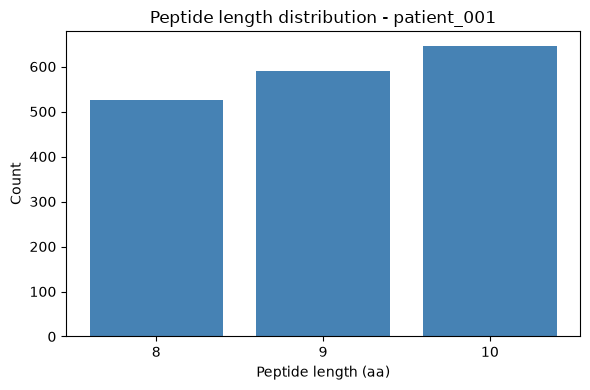

In [4]:
peptides = r2_read_tsv_cached(f"{PREFIX}/peptides/peptides_novel.tsv")
print(f"Total peptides: {len(peptides):,}")
print(f"Unique sequences: {peptides['peptide'].nunique():,}")

length_counts = peptides["peptide"].str.len().value_counts().sort_index()
print(f"\nPeptide length distribution:")
print(length_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(length_counts.index, length_counts.values, color="steelblue")
ax.set_xlabel("Peptide length (aa)")
ax.set_ylabel("Count")
ax.set_title("Peptide length distribution - patient_001")
ax.set_xticks(length_counts.index)
plt.tight_layout()
plt.show()

## 4. MHC Prediction Summary

### 4.1 Presentation class breakdown

How do peptide-allele predictions distribute across the strong (≤ 0.5th percentile), weak (≤ 2nd percentile), and non-presenter classes?

Total predictions loaded: 1,761

Presentation class breakdown:
presentation_class
strong      32
weak       188
non       1541


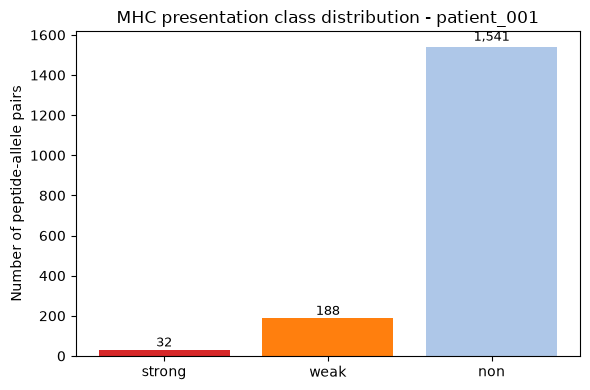

In [5]:
pres = r2_read_tsv_cached(f"{PREFIX}/predictions/mhc_presentation.tsv")
print(f"Total predictions loaded: {len(pres):,}")

class_counts = pres["presentation_class"].value_counts().reindex(["strong", "weak", "non"], fill_value=0)
print("\nPresentation class breakdown:")
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=["#d62728", "#ff7f0e", "#aec7e8"])
ax.set_ylabel("Number of peptide-allele pairs")
ax.set_title("MHC presentation class distribution - patient_001")
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 HLA allele dominance

Which alleles present the 17 strong-class peptides? patient_001's MHCflurry predictions ran against the tumor HLA calls: HLA-A\*31:01/A\*26:01, HLA-B\*15:63/B\*18:01, HLA-C\*07:01/C\*03:03. patient_002 showed strong HLA-C dominance (HLA-C\*01:02 / C\*07:01 ≈ 69% of strong presenters) - does it recapitulate here with different HLA-C alleles? (The cross-patient comparison is provisional: patient_002's stored numbers are still pre-#370 and await regeneration under Issue #212 / #378.)

Strong presenters per allele:
best_allele
HLA-C*07:01    12
HLA-C*01:02     8
HLA-B*08:01     7
HLA-B*27:05     3
HLA-A*01:01     2


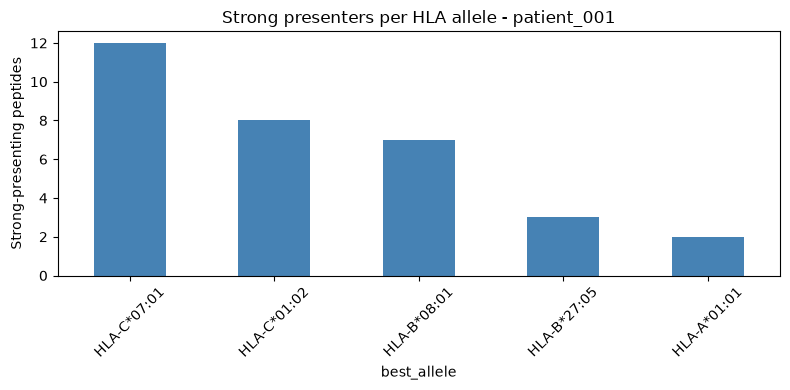

In [6]:
strong = pres[pres["presentation_class"] == "strong"]
allele_counts = strong["best_allele"].value_counts()
print("Strong presenters per allele:")
print(allele_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
allele_counts.plot(kind="bar", ax=ax, color="steelblue", rot=45)
ax.set_ylabel("Strong-presenting peptides")
ax.set_title("Strong presenters per HLA allele - patient_001")
plt.tight_layout()
plt.show()

## 5. Top Candidates

### 5.1 Top 20 by genotype presentation score

`genotype_presentation_score` (GPS) ranks candidates across the full patient HLA genotype - it rewards peptides presented by multiple alleles. This is the primary ranking used for prioritisation.

In [7]:
top20 = (pres.sort_values("genotype_presentation_score", ascending=False)
           .head(20)
           [["peptide", "best_allele", "ic50_nM", "presentation_percentile",
             "genotype_presentation_score", "n_strong_alleles", "presentation_class"]])
top20.reset_index(drop=True, inplace=True)
top20.index += 1
top20

,peptide,best_allele,ic50_nM,presentation_percentile,genotype_presentation_score,n_strong_alleles,presentation_class
1,VPQVRVTVL,HLA-B*08:01,38.006002,0.008424,0.997769,3,strong
2,SLAWRNISL,HLA-B*08:01,43.816093,0.084783,0.990063,3,strong
3,ARIYWISHY,HLA-C*07:01,50.253649,0.015380,0.985642,2,strong
4,GQISLPLSL,HLA-C*07:01,49.436544,0.036957,0.984090,3,strong
5,EFIGYPITL,HLA-C*01:02,118.287230,0.068560,0.981896,3,strong
6,LRPGSHSQL,HLA-C*07:01,59.875176,0.077826,0.958109,3,strong
7,AVRLKIIIL,HLA-B*08:01,51.172252,0.173424,0.955942,1,strong
8,GSQPFKVFY,HLA-A*01:01,116.113501,0.103940,0.955752,1,strong
9,AWIDVIQLL,HLA-C*01:02,216.393355,0.203859,0.919763,3,strong
10,VPQVRVTV,HLA-B*08:01,90.319432,0.144783,0.904418,1,strong


### 5.2 Top candidate: VPQVRVTVL / HLA-B\*08:01

**IC50 = 38.0 nM | presentation_percentile = 0.0084% | GPS = 0.9978 | n_strong_alleles = 3**

Key observations:
- IC50 ~38 nM and a 0.008th-percentile call place VPQVRVTVL firmly in strong-presenter territory, presented as strong by 3 of 5 alleles (GPS ~ 0.998).
- **Matched-normal caveat (see banner at top):** VPQVRVTVL's originating junction cleared only a CD3+ T-cell PBMC normal (plus the GTEx pan-tissue filter), *not* a tissue-matched normal, so its tumor-specificity is **not** established. It is recorded here, not asserted as a validated candidate.

## 6. Genotype Presentation Score (GPS) - Validation

GPS = $1 - \prod_i (1 - w_i \cdot p_i)$ where $p_i$ is per-allele `presentation_score` and $w_i$ is locus weight (HLA-A/B = 1.0, HLA-C = 0.5; the weighting is approximate - MHCflurry applies its own locus-aware calibration internally during scoring). It estimates the probability that **at least one allele** in the patient's genotype presents the peptide. Primary ranking signal for the vaccine context; backed by a quality gate (`best_presentation_percentile ≤ 2%`).

Questions to answer empirically:
1. How is GPS distributed across all predictions - is it discriminating or does everyone score high?
2. Does GPS correlate with `n_strong_alleles` as expected?
3. Are there candidates with high GPS but poor best-allele percentile (the "inflation" edge case)?
4. Per-allele contribution: which alleles drive GPS most in this patient?

### 6.1 GPS distribution

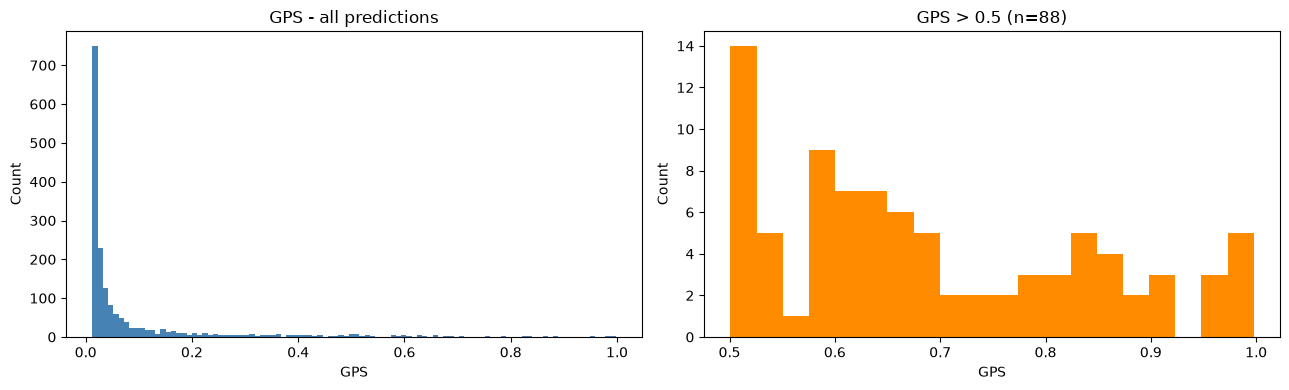


GPS summary stats:
count    1761.000000
mean        0.097050
std         0.167656
min         0.012562
25%         0.016864
50%         0.027088
75%         0.077994
max         0.997769

GPS > 0.9: 10
GPS > 0.99: 2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution
axes[0].hist(pres["genotype_presentation_score"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("GPS")
axes[0].set_ylabel("Count")
axes[0].set_title("GPS - all predictions")

# Zoom into the high end (> 0.5) where interesting candidates live.
# Only ~14 points exceed 0.5 in the corrected set, so use few bins (100 would
# leave mostly-empty bins - the same small-n critique as the read-support figure).
high = pres[pres["genotype_presentation_score"] > 0.5]
axes[1].hist(high["genotype_presentation_score"], bins=20, color="darkorange", edgecolor="none")
axes[1].set_xlabel("GPS")
axes[1].set_ylabel("Count")
axes[1].set_title(f"GPS > 0.5 (n={len(high):,})")

plt.tight_layout()
plt.show()

print(f"\nGPS summary stats:")
print(pres["genotype_presentation_score"].describe().to_string())
print(f"\nGPS > 0.9: {(pres['genotype_presentation_score'] > 0.9).sum():,}")
print(f"GPS > 0.99: {(pres['genotype_presentation_score'] > 0.99).sum():,}")

### 6.2 GPS vs n_strong_alleles - does breadth drive the score?

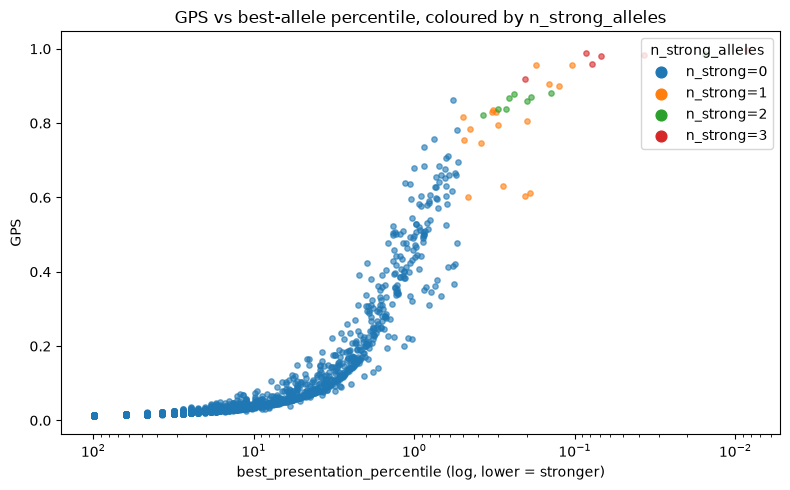

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for n, grp in pres.groupby("n_strong_alleles"):
    ax.scatter(grp["best_presentation_percentile"], grp["genotype_presentation_score"],
               alpha=0.6, s=15, label=f"n_strong={n}")

ax.set_xscale("log")
ax.set_xlabel("best_presentation_percentile (log, lower = stronger)")
ax.set_ylabel("GPS")
ax.set_title("GPS vs best-allele percentile, coloured by n_strong_alleles")
ax.invert_xaxis()
legend = ax.legend(markerscale=2, title="n_strong_alleles", loc="upper right")
for lh in legend.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
plt.show()

### 6.3 Inflation check - high GPS with no strong allele

The GPS-inflation edge case (GPS > 0.9 driven by allele breadth while no single allele clears the strong threshold) is what the current quality gate (`best_presentation_percentile ≤ 2%`) does not catch. With only 395 predictions in the corrected set, there are **zero** such cases here (vs 25 in the old buggy patient_001 set and 174 in patient_002) - at this n the edge case is essentially absent.

In [10]:
# Candidates with GPS > 0.9 but n_strong_alleles == 0.
# These are NOT caught by the current quality gate (best_presentation_percentile <= 2%) -
# their best_percentile is just above the strong threshold (0.5%), so GPS inflates from
# allele breadth rather than per-allele strength.
# patient_002 had 174 such cases; comparing here.
inflated = pres[(pres["genotype_presentation_score"] > 0.9) & (pres["n_strong_alleles"] == 0)]
print(f"GPS > 0.9 with n_strong_alleles = 0: {len(inflated):,}")
if len(inflated) > 0:
    print("\nTop 10 by GPS:")
    print(inflated.nlargest(10, "genotype_presentation_score")
          [["peptide", "best_allele", "best_presentation_percentile",
            "genotype_presentation_score", "n_strong_alleles"]].to_string())

GPS > 0.9 with n_strong_alleles = 0: 0


### 6.4 Per-allele contribution to GPS

     allele  median_pres_score_strong  pct_as_best_allele  median_percentile_strong
HLA-A*01:01                  0.021687               6.250                 10.885815
HLA-B*08:01                  0.086521              21.875                  3.262446
HLA-B*27:05                  0.662358               9.375                  0.504062
HLA-C*01:02                  0.159229              25.000                  2.142228
HLA-C*07:01                  0.583137              37.500                  0.649348


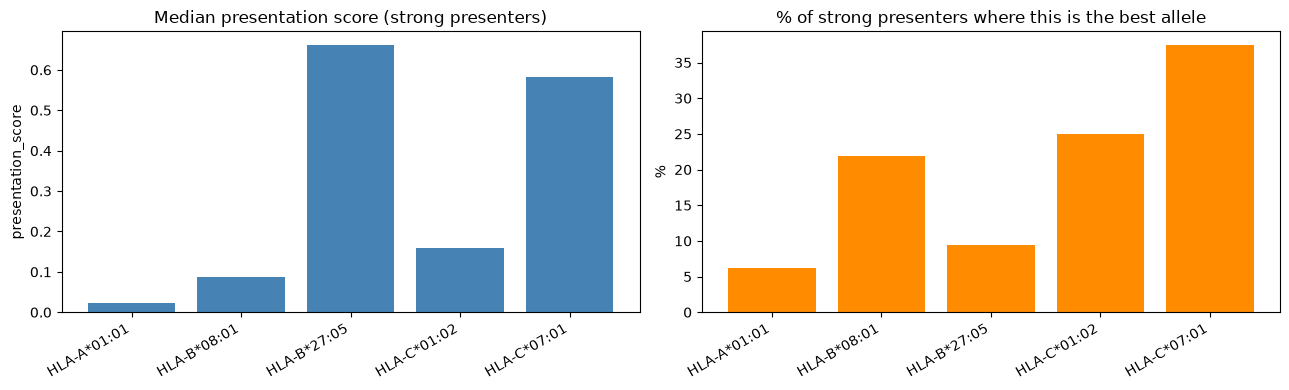

In [11]:
# Derive alleles from column names - works across patients without modification
alleles = sorted([c.replace("_presentation_score", "")
                  for c in pres.columns if c.endswith("_presentation_score")
                  and c.startswith("HLA-")])
score_cols = [f"{a}_presentation_score" for a in alleles]
pct_cols   = [f"{a}_presentation_percentile" for a in alleles]

strong = pres[pres["presentation_class"] == "strong"]
n_strong = len(strong) or 1  # guard: a future patient may have zero strong presenters

summary = pd.DataFrame({
    "allele": alleles,
    "median_pres_score_strong": [strong[c].median() for c in score_cols],
    "pct_as_best_allele": [
        (strong["best_allele"] == a).sum() / n_strong * 100 for a in alleles
    ],
    "median_percentile_strong": [strong[c].median() for c in pct_cols],
})
print(summary.to_string(index=False))

x = range(len(summary))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(x, summary["median_pres_score_strong"], color="steelblue")
axes[0].set_title("Median presentation score (strong presenters)")
axes[0].set_ylabel("presentation_score")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(summary["allele"], rotation=30, ha="right")

axes[1].bar(x, summary["pct_as_best_allele"], color="darkorange")
axes[1].set_title("% of strong presenters where this is the best allele")
axes[1].set_ylabel("%")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(summary["allele"], rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 7. Scientific Summary & Open Questions

> **Scope note:** this notebook regenerates the corrected 2026-06-23 STAR run for the record. Because patient_002 lacks a tissue-matched normal (its only normal is a CD3+ T-cell PBMC), these numbers are **not** presented as a validated second result in the manuscript - patient_002 is reframed as a matched-normal *limitation case* (Issue #636 AC3; RESULTS.md).

### Numbers (for the record)

1. **42 nominal tumor_exclusive junctions** - of 442 unannotated junctions, 154 are shared with the CD3+ T-cell PBMC normal and 246 with the GTEx pan-tissue reference, leaving 42. These are **not tissue-specificity-controlled**: a T-cell normal cannot subtract bone/mesenchymal splicing, and GTEx does far more of the filtering here (246) than for patient_001 (39).
2. **1,761 novel peptides** (8/9/10-mer: 525 / 590 / 646) -> **32 strong + 188 weak presenters** of 1,761 predictions.
3. **HLA-C dominance** - 20 of 32 strong presenters (62.5%) are HLA-C (C\*07:01 = 12, C\*01:02 = 8), echoing patient_001's HLA-C skew despite different alleles.
4. **Top candidate VPQVRVTVL / HLA-B\*08:01** - IC50 38.0 nM, percentile 0.0084%, GPS 0.9978, strong across 3/5 alleles. Recorded, not asserted (see the matched-normal caveat).
5. **GPS** - mean 0.097, median 0.027; 10 of 1,761 predictions exceed GPS 0.9; zero GPS-inflation edge cases (GPS > 0.9 with n_strong_alleles = 0).
6. **Deep read support** - the 42 tumor_exclusive junctions have median 373 mapped reads (vs 28 for patient_001), reflecting a different tumor/library, not stronger tumor-specificity.

### Open questions / next steps

- **A defensible patient_002 candidate set** needs a tissue-appropriate normal, or an explicit population-only mode (blood normal excluded from subtraction, GTEx retained) - tracked in Issue #940.
- **HLA typing is the solid result** - patient_002's OptiType calls are Red Cross serology-validated (the first such validation in the pipeline); that result is independent of the matched-normal limitation.
- **Cross-patient comparison with patient_001 is deliberately not drawn** - the two tumor_exclusive sets went through different normal-subtraction regimes and are not comparable.